In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Load the data
df = pd.read_excel('/Users/rishabhkumar/spiral-chirals/distributional-data/EE-1-04-4500x.xlsx')

# 1. Parse Coordinates: "(x, y)" -> [x, y]
def parse_coord(coord_str):
    # Regex to extract numbers from string like "(9.00, 0.00)"
    matches = re.findall(r"[-+]?\d*\.\d+|\d+", coord_str)
    return [float(matches[0]), float(matches[1])]

coords = np.array(df['Coordinate'].apply(parse_coord).tolist())

# 2. Extract Distributional Data (The Y variable)
# Columns Ideg_000 to Ideg_175
ideg_cols = [c for c in df.columns if c.startswith('Ideg_')]
distributions = df[ideg_cols].values  # Shape: (N_samples, 36)

# Normalize the distributions (optional, but good for mathematical consistency implies integral=1)
# Assuming 5-degree steps
row_sums = distributions.sum(axis=1, keepdims=True)
distributions_normalized = distributions / row_sums

# Define the angles for the bins (0 to 175)
angles = np.arange(0, 180, 5)

In [20]:
class DistributionalKernelRegression:
    def __init__(self, bandwidth=20.0, kernel='gaussian'):
        self.h = bandwidth
        self.kernel_type = kernel
        self.X_train = None
        self.Y_train = None

    def fit(self, X, Y):
        """
        X: Spatial coordinates (N, 2)
        Y: Intensity distributions (N, 36)
        """
        self.X_train = X
        self.Y_train = Y

    def _kernel_func(self, dists):
        if self.kernel_type == 'gaussian':
            return np.exp(-0.5 * (dists / self.h) ** 2)
        elif self.kernel_type == 'epanechnikov':
            k = 0.75 * (1 - (dists / self.h) ** 2)
            k[dists > self.h] = 0
            return k
        else:
            raise ValueError("Unknown kernel")

    def predict(self, X_query):
        """
        Returns the interpolated distribution at query points.
        """
        # Compute distances between query points and training points
        dists = cdist(X_query, self.X_train, metric='euclidean')
        
        # Compute Kernel Weights
        # Shape: (N_query, N_train)
        weights = self._kernel_func(dists)
        
        # Normalize weights (Nadaraya-Watson denominator)
        # Add epsilon to avoid division by zero
        sum_weights = weights.sum(axis=1, keepdims=True) + 1e-10
        W_norm = weights / sum_weights
        
        # Compute weighted average of distributions
        # (N_query, N_train) @ (N_train, 36) -> (N_query, 36)
        Y_pred = W_norm @ self.Y_train
        
        return Y_pred

# Initialize and Fit
# Bandwidth selection is critical. For this data range (~300 units), 
# a bandwidth of 30-50 usually captures the local field well.
dkr = DistributionalKernelRegression(bandwidth=200.0, kernel='epanechnikov')
dkr.fit(coords, distributions_normalized)

/var/folders/kq/dktrln_x0tgf7tr54wrn711r0000gn/T/ipykernel_92411/1713092130.py:44: RuntimeWarning: divide by zero encountered in matmul
  Y_pred = W_norm @ self.Y_train
/var/folders/kq/dktrln_x0tgf7tr54wrn711r0000gn/T/ipykernel_92411/1713092130.py:44: RuntimeWarning: overflow encountered in matmul
  Y_pred = W_norm @ self.Y_train
/var/folders/kq/dktrln_x0tgf7tr54wrn711r0000gn/T/ipykernel_92411/1713092130.py:44: RuntimeWarning: invalid value encountered in matmul
  Y_pred = W_norm @ self.Y_train


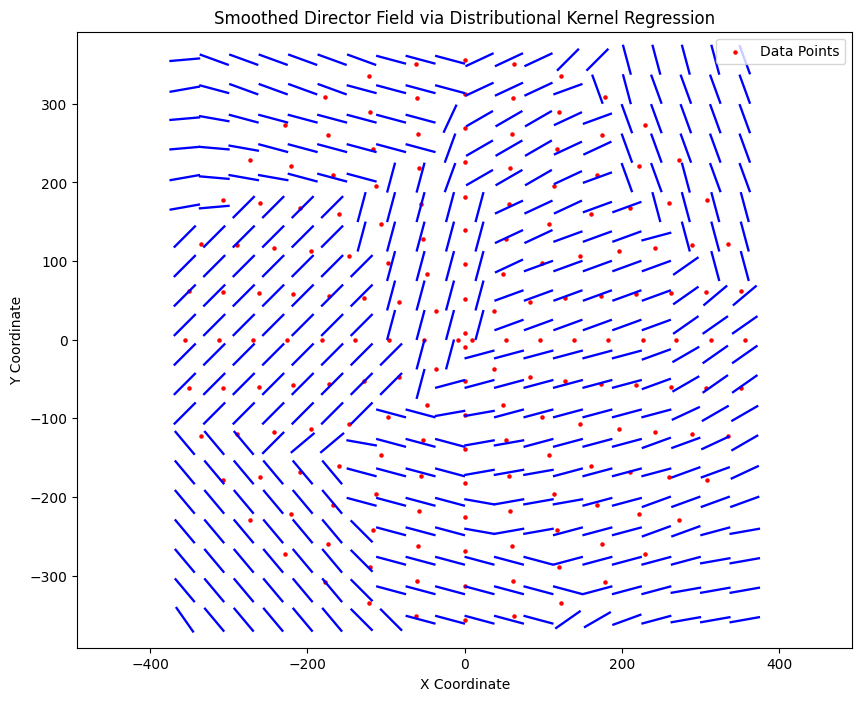

In [21]:
# Create a grid for visualization
x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
y_min, y_max = coords[:, 1].min(), coords[:, 1].max()
grid_x, grid_y = np.mgrid[x_min:x_max:20j, y_min:y_max:20j]
X_grid = np.vstack([grid_x.ravel(), grid_y.ravel()]).T

# Predict distributions on the grid
Y_grid_dist = dkr.predict(X_grid)

# Extract the "Director" (Peak Angle) from the smoothed distributions
# This recovers the vector field from the distributional field
peak_indices = np.argmax(Y_grid_dist, axis=1)
peak_angles_deg = angles[peak_indices]
peak_angles_rad = np.deg2rad(peak_angles_deg)

# Convert angles to vector components (u, v) for plotting
# Note: Nematic symmetry means arrow points both ways, but quiver needs a direction.
U = np.cos(peak_angles_rad)
V = np.sin(peak_angles_rad)

# Visualization
plt.figure(figsize=(10, 8))
plt.title("Smoothed Director Field via Distributional Kernel Regression")

# 1. Plot the original sampling points
plt.scatter(coords[:, 0], coords[:, 1], c='red', s=5, label='Data Points')

# 2. Plot the interpolated vector field
plt.quiver(X_grid[:, 0], X_grid[:, 1], U, V, 
           pivot='mid', color='blue', scale=25, headlength=0, headaxislength=0) 
           # headlength=0 makes it look like a line (nematic) rather than an arrow

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.axis('equal')
plt.legend()
plt.show()